In [6]:
install.packages("clustree")

also installing the dependencies ‘viridis’, ‘tidygraph’





The downloaded binary packages are in
	/var/folders/yp/rq67n9wd35vfkdbx07pvj2k80000gp/T//RtmpI7bKBg/downloaded_packages


In [7]:
##load all the libraries required for the analysis

library(Seurat)
library(ggplot2)
library(patchwork)
library(clustree)
library(magrittr)
library(tidyverse)

Loading required package: ggraph


Attaching package: ‘ggraph’


The following object is masked from ‘package:sp’:

    geometry


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::extract()   masks magrittr::extract()
✖ dplyr::filter()    masks stats::filter()
✖ dplyr::lag()       masks stats::lag()
✖ purrr::set_names() masks magrittr::set_names()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [8]:
#There are multiple run unmder the GEO dataset Series GSE84133 and under GPL16791 platform there are many samples and from that I have chosen GSM2230759 which is a human sample of pancreas

raw_df <- read.csv("~/Downloads/GSM2230759_human3_umifm_counts.csv", header = TRUE, row.names = 1)


In [9]:
#excluding the first 3 columns as reequired by the seurat to process the data and also excluding the pre defined cluster names from the study to analyse only the genes
expr_matrix <- t(raw_df[, 3:ncol(raw_df)])


In [10]:
#converting the gene expression data into matrix and to numeric
expr_matrix <- as.matrix(expr_matrix)
mode(expr_matrix) <- "numeric"

In [11]:
# Creating the Seurat object from matrix
seurat_obj <- CreateSeuratObject(counts = expr_matrix, project = "GSE84133", min.cells = 3, min.features = 200)


Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”


In [12]:
#normalise the gene data from the counts
seurat_obj <- NormalizeData(seurat_obj)


Normalizing layer: counts



In [13]:
#finding the variable genes using the variance stabilizing transformation and picking the top 2000 highly variable genes
seurat_obj <- FindVariableFeatures(seurat_obj, selection.method = "vst", nfeatures = 2000)


Finding variable features for layer counts



In [14]:
#scaling the data to get the average expresssion levels fro each gene
seurat_obj <- ScaleData(seurat_obj)


Centering and scaling data matrix



In [15]:
#Running the PCA to get the genes which are significant
seurat_obj <- RunPCA(seurat_obj, features = VariableFeatures(object = seurat_obj))


PC_ 1 
Positive:  IFITM3, PMEPA1, TMSB10, MSN, CDC42EP1, ZFP36L1, YBX3, ITGA2, SOX4, IL32 
	   S100A16, TACSTD2, KRT7, SDC4, RHOC, TUBA1C, CD44, PLIN2, PFKFB3, C8orf4 
	   IFITM2, ITGA5, DDIT4, TUBB6, TMSB4X, ANGPTL4, FAM129B, PRSS8, ETS2, KRT18 
Negative:  CHGA, CHGB, VGF, SCG2, PEMT, SCGN, NLRP1, PTPRN, PPP1R1A, GAD2 
	   UCHL1, PCSK2, GPX3, PAX6, CLU, GNG4, CNIH2, TMEM176B, TMEM176A, TUBA1A 
	   C2CD4A, CPLX2, C2CD4B, SYNGR4, SYT5, STX1A, NEUROD1, ERO1B, PCP4, DPP6 
PC_ 2 
Positive:  CPA2, SPINK1, PLA2G1B, CELA3B, CLPS, CTRC, PRSS1, CTRB1, PNLIPRP1, CELA3A 
	   CPB1, PRSS2, CTRB2, KLK1, CPA1, CELA2A, SYCN, PNLIPRP2, SERPINA3, PNLIP 
	   PRSS3, REG1B, GP2, CD24, CTRL, FOXD2, CELA2B, CUZD1, REG1P, MGST1 
Negative:  SPARC, ENG, PXDN, IGFBP7, IGFBP4, COL6A2, TIMP1, BGN, SERPINE1, ADAMTS4 
	   COL4A1, PDGFRB, AEBP1, COL15A1, COL6A1, TBX3, HIC1, HTRA3, EMP1, COL1A1 
	   SLC2A3, CRISPLD2, EMILIN1, ITGA5, LRRC32, HMOX1, NRP2, PPAP2B, COL6A3, TCF4 
PC_ 3 
Positive:  PNLIPRP1, CPA2, CTRC, CEL

In [16]:
#finding the genes which defines each cluster using 10 dimensions
seurat_obj <- FindNeighbors(seurat_obj, dims = 1:10)


Computing nearest neighbor graph

Computing SNN



In [17]:
#Finding the clusters
seurat_obj <- FindClusters(seurat_obj, resolution = 0.5)


Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 3605
Number of edges: 115648

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8991
Number of communities: 11
Elapsed time: 0 seconds


In [18]:
#UMAP to cluster into 2d space
seurat_obj <- RunUMAP(seurat_obj, dims = 1:10)


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
21:16:20 UMAP embedding parameters a = 0.9922 b = 1.112

21:16:20 Read 3605 rows and found 10 numeric columns

21:16:20 Using Annoy for neighbor search, n_neighbors = 30

21:16:20 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

21:16:20 Writing NN index file to temp file /var/folders/yp/rq67n9wd35vfkdbx07pvj2k80000gp/T//RtmpI7bKBg/file2f0545890b10

21:16:20 Searching Annoy index using 1 thread, search_k = 3000

21:16:21 Annoy recall = 100%

21:16:21 Commencing smooth kNN distance calibrat

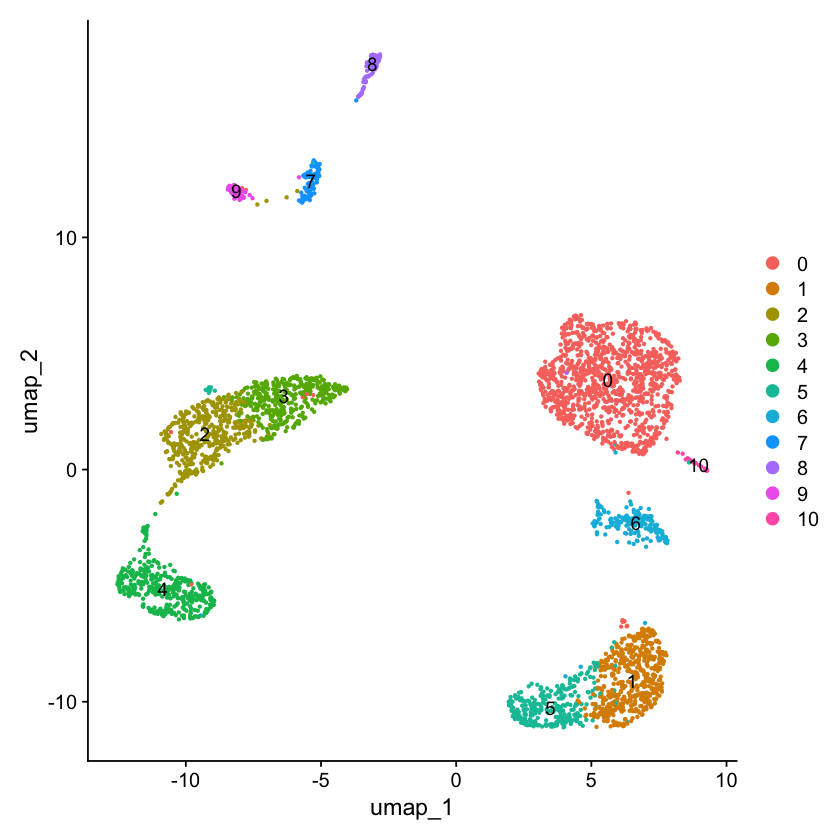

In [19]:
#plotting the clusters
DimPlot(seurat_obj, reduction = "umap", label = TRUE)


#Finding the markers present in atleast 25% of the cells in each cluster
cluster_markers <- FindAllMarkers(seurat_obj, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25)
head(cluster_markers)


In [24]:
cluster_markers <- FindAllMarkers(seurat_obj, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25)
head(cluster_markers)

Calculating cluster Alpha

For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session

Calculating cluster Delta

Calculating cluster Unknown

Calculating cluster Acinar

Calculating cluster Ductal

Calculating cluster Beta

Calculating cluster Stellate

Calculating cluster Endothelial

Calculating cluster Immune

Calculating cluster Mast cells



,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
GC,0,6.492749,0.789,0.019,0,Alpha,GC
MUC13,0,5.761739,0.791,0.078,0,Alpha,MUC13
IRX2,0,5.938625,0.724,0.026,0,Alpha,IRX2
PCSK2,0,3.381922,0.914,0.233,0,Alpha,PCSK2
RGS4,0,5.081726,0.714,0.063,0,Alpha,RGS4
GPX3,0,2.998051,0.989,0.374,0,Alpha,GPX3


In [25]:
#getting the top markers cor each cluster which has log2 fold change diffference
top_markers <- cluster_markers %>% group_by(cluster) %>% top_n(n = 2, wt = avg_log2FC)
top_markers

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
0.000000e+00,6.492749,0.789,0.019,0.000000e+00,Alpha,GC
0.000000e+00,6.833247,0.992,0.425,0.000000e+00,Alpha,GCG
3.276848e-223,4.834518,0.568,0.074,4.989985e-219,Delta,RBP4
1.841444e-29,6.347723,0.603,0.443,2.804151e-25,Delta,SST
1.453986e-171,3.443171,0.474,0.048,2.214130e-167,Unknown,FAM13A
2.788663e-112,3.633487,0.273,0.020,4.246576e-108,Unknown,C6orf222
9.611826e-227,3.612705,0.982,0.336,1.463689e-222,Acinar,REG1B
1.048107e-174,3.716638,0.695,0.130,1.596058e-170,Acinar,REG3G
0.000000e+00,8.852792,0.680,0.007,0.000000e+00,Ductal,MMP7


In [56]:
#Based on the markers associated with the cell types from the articles https://doi.org/10.1016/j.cels.2016.08.011
#The top markers from the above genes, the cluster from 0 to 10 can be renamed as follows
#GC, GCG----Alpha
#ADCYAP1, RGS16------Delta
#FAM13A, C6orf222------Unknown / Intermediate
#REG1B, REG3G-------Acinar
#MMP7, KRT23-------Ductal
#INS, DHRS2-------Beta
#RBP4, SST------Delta
#SFRP2, C7-------Stellate / Mesenchymal
#KDR, ADGRL4------Endothelial
#IL24, RGS5------Immune / Macrophage-like
#SDS, TPSAB-------Mast / Immune cells




In [21]:
#new names for each cluster
new_cluster_ids <- c(
  "Alpha",        # 0
  "Delta",        # 1
  "Unknown",      # 2
  "Acinar",       # 3
  "Ductal",       # 4
  "Beta",         # 5
  "Delta",        # 6
  "Stellate",     # 7
  "Endothelial",  # 8
  "Immune",       # 9
  "Mast cells"    # 10
)

In [22]:
#remnaming the clusters based on the markers
names(new_cluster_ids) <- levels(seurat_obj)
seurat_obj <- RenameIdents(seurat_obj, new_cluster_ids)

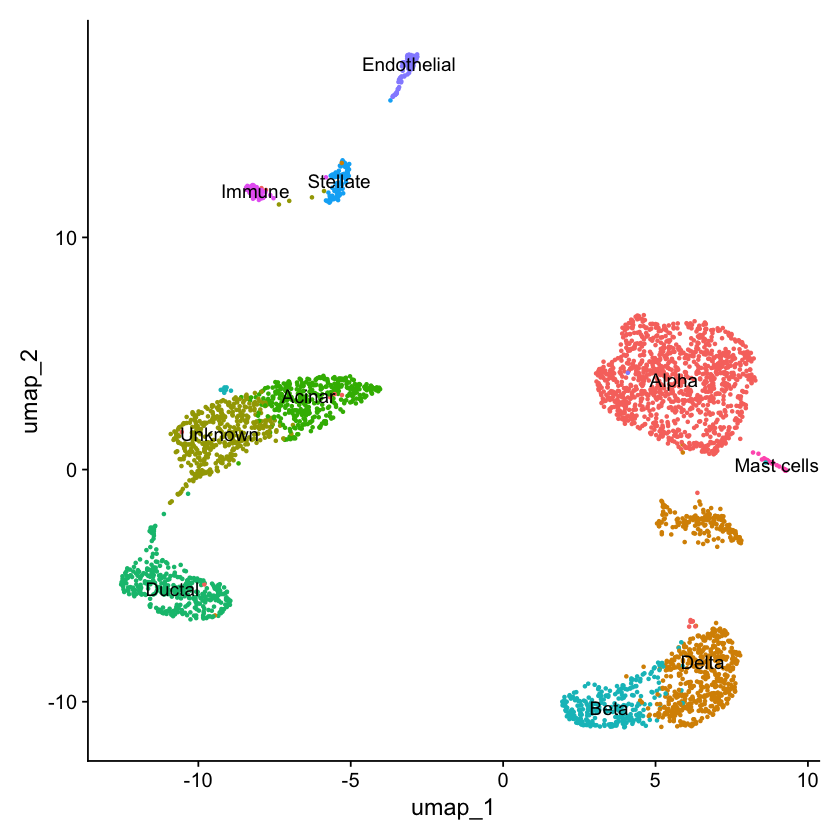

In [23]:
# Visualizing the clusters with new names
DimPlot(seurat_obj, reduction = "umap", label = TRUE, pt.size = 0.5) + NoLegend()